<a href="https://colab.research.google.com/github/avani-joshii/rl-racing-agent/blob/main/rl_car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium stable-baselines3 matplotlib numpy

In [2]:
# @title
%%writefile race_env.py
"""
race_env.py  —  A custom 2D racing environment built on Gymnasium.
The track is an oval. The car has position, heading and speed."""

import numpy as np
import gymnasium
import gymnasium as gym
from gymnasium import spaces
import math


# The track is an ellipse
TRACK_A = 6.0
TRACK_B = 3.5
TRACK_WIDTH = 2.0
INNER_A = TRACK_A - TRACK_WIDTH
INNER_B = TRACK_B - TRACK_WIDTH
OUTER_A = TRACK_A
OUTER_B = TRACK_B


def on_track(x, y):
    """Return True if point is on the driveable track surface."""
    inner = (x / INNER_A) ** 2 + (y / INNER_B) ** 2
    outer = (x / OUTER_A) ** 2 + (y / OUTER_B) ** 2
    return inner >= 1.0 and outer <= 1.0


def track_progress(x, y):

    angle = math.atan2(y / TRACK_B, x / TRACK_A)
    # atan2 returns [-pi, pi]; map to [0, 1)
    return (angle % (2 * math.pi)) / (2 * math.pi)


class RaceEnv(gymnasium.Env):
    """
    A simple 2D oval racing environment.

    Observation space (7 values — the STATE):
        [0] speed            — current speed (m/s), normalised to [0,1]
        [1] heading_sin      — sin of heading angle
        [2] heading_cos      — cos of heading angle
        [3-6] raycasts × 7  — distances to nearest wall in 7 directions,
                               normalised to [0,1]  (0 = wall right here,
                                                      1 = wall very far)"""

    metadata = {"render_modes": ["human", "rgb_array"]}

    def __init__(self, render_mode=None):
        super().__init__()


        # 5 discrete actions: nothing, accelerate, brake, left, right
        self.action_space = spaces.Discrete(5)


        # [speed, sin_heading, cos_heading, ray0..ray6]
        low  = np.array([ 0, -1, -1,  0, 0, 0, 0, 0, 0, 0], dtype=np.float32)
        high = np.array([ 1,  1,  1,  1, 1, 1, 1, 1, 1, 1], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        # Physics stuff
        self.max_speed    = 5.0   # m/s
        self.accel        = 0.5   # m/s² per step
        self.brake_force  = 0.8   # m/s² deceleration
        self.drag         = 0.05  # passive speed loss per step
        self.steer_angle  = 0.12  # radians per step

        # Raycast angles relative to car heading (7 beams)
        self.ray_angles = np.array(
            [0, -0.4, 0.4, -1.2, 1.2, -2.5, 2.5], dtype=np.float32
        )
        self.ray_max = 5.0

        self.render_mode = render_mode
        self._screen = None

        # Lap tracking
        self._prev_progress = None
        self._lap_crossings = 0

    # to reset itt
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)


        self.x       = TRACK_A - TRACK_WIDTH / 2
        self.y       = 0.0
        self.heading = math.pi / 2
        self.speed   = 0.5

        self._prev_progress = track_progress(self.x, self.y)
        self._lap_crossings = 0
        self._step_count = 0

        return self._get_obs(), {}


    def step(self, action):
        """
        Apply action, update physics, compute reward, check termination.

        Reward function (WHY this design):
          +progress_reward  — proportional to how much further around the
                              track the car moved. Encourages forward motion.
          -0.01 per step    — small time penalty so the agent learns to be
                              fast, not just survive.
          +5.0 for a lap    — big reward for completing a full lap.
          -3.0 for crash    — large penalty for going off track. Episode ends."""

        # action
        if action == 1:   # accelerate
            self.speed = min(self.max_speed, self.speed + self.accel)
        elif action == 2:  # brake
            self.speed = max(0.0, self.speed - self.brake_force)
        elif action == 3:  # go left
            self.heading += self.steer_angle
        elif action == 4:  # go right
            self.heading -= self.steer_angle
        # action == 0: do nothing


        self.speed = max(0.0, self.speed - self.drag)

        # Move
        self.x += math.cos(self.heading) * self.speed * 0.1
        self.y += math.sin(self.heading) * self.speed * 0.1
        self._step_count += 1

        #see if crasehd
        crashed = not on_track(self.x, self.y)

        # calculate rewards so far
        current_progress = track_progress(self.x, self.y)
        delta = current_progress - self._prev_progress


        if delta < -0.5:
            delta += 1.0
            self._lap_crossings += 1
        elif delta > 0.5:   # wrapped backward (0.01 → 0.99) = going wrong way
            delta -= 1.0

        self._prev_progress = current_progress

        progress_reward = delta * 10.0
        time_penalty    = -0.01
        lap_bonus       = 5.0 if self._lap_crossings > 0 else 0.0
        self._lap_crossings = 0

        if crashed:
            reward = -3.0
        else:
            reward = progress_reward + time_penalty + lap_bonus

        # termination
        terminated = crashed
        truncated  = self._step_count >= 1000

        obs = self._get_obs()
        info = {
            "progress": current_progress,
            "speed": self.speed,
            "crashed": crashed,
        }

        if self.render_mode == "human":
            self._render_frame()

        return obs, reward, terminated, truncated, info

    # Observations
    def _get_obs(self):
        """Build the 10-dimensional state vector the agent observes."""
        speed_norm   = self.speed / self.max_speed
        sin_h        = math.sin(self.heading)
        cos_h        = math.cos(self.heading)
        rays         = self._cast_rays()
        return np.array(
            [speed_norm, sin_h, cos_h] + rays, dtype=np.float32
        )

    def _cast_rays(self):

        distances = []
        for angle_offset in self.ray_angles:
            ray_angle = self.heading + angle_offset
            dx = math.cos(ray_angle) * 0.1
            dy = math.sin(ray_angle) * 0.1
            rx, ry = self.x, self.y
            dist = 0.0
            for _ in range(int(self.ray_max / 0.1)):
                rx += dx
                ry += dy
                dist += 0.1
                if not on_track(rx, ry):
                    break
            distances.append(min(dist, self.ray_max) / self.ray_max)
        return distances

    # render
    def render(self):
        if self.render_mode == "rgb_array":
            return self._render_frame()

    def _render_frame(self):
        try:
            import pygame
        except ImportError:
            return None

        W, H = 600, 400
        scale = 40   # pixels per world unit
        cx, cy = W // 2, H // 2

        def w2s(wx, wy):
            return int(cx + wx * scale), int(cy - wy * scale)

        if self._screen is None:
            pygame.init()
            if self.render_mode == "human":
                self._screen = pygame.display.set_mode((W, H))
                pygame.display.set_caption("RL Racing Agent")
            else:
                self._screen = pygame.Surface((W, H))

        surf = self._screen
        surf.fill((30, 30, 30))

        # Draw track (sample points around the oval)
        for i in range(360):
            theta = math.radians(i)
            for r in np.linspace(0.5, 1.0, 6):
                ox = OUTER_A * math.cos(theta) * r + (OUTER_A * (1 - r))
                oy = OUTER_B * math.sin(theta)
            # Draw outer and inner oval edges
            ox = OUTER_A * math.cos(theta)
            oy = OUTER_B * math.sin(theta)
            ix = INNER_A * math.cos(theta)
            iy = INNER_B * math.sin(theta)
            pygame.draw.circle(surf, (80, 80, 80), w2s(ox, oy), 2)
            pygame.draw.circle(surf, (80, 80, 80), w2s(ix, iy), 2)

        # Fill track surface
        for theta in np.linspace(0, 2 * math.pi, 400):
            for t in np.linspace(0.01, 0.99, 10):
                tx = (INNER_A + (OUTER_A - INNER_A) * t) * math.cos(theta)
                ty = (INNER_B + (OUTER_B - INNER_B) * t) * math.sin(theta)
                pygame.draw.circle(surf, (60, 60, 60), w2s(tx, ty), 3)

        # Start/finish line
        sx, sy = w2s(OUTER_A, 0)
        ix2, iy2 = w2s(INNER_A, 0)
        pygame.draw.line(surf, (255, 50, 50), (sx, sy), (ix2, iy2), 3)

        # Draw raycasts
        for angle_offset in self.ray_angles:
            ray_angle = self.heading + angle_offset
            end_x = self.x + math.cos(ray_angle) * 1.5
            end_y = self.y + math.sin(ray_angle) * 1.5
            pygame.draw.line(surf, (0, 150, 200),
                             w2s(self.x, self.y), w2s(end_x, end_y), 1)

        # Draw car
        car_pts = []
        for ang, r in [(-0.4, 0.25), (0.4, 0.25), (2.7, 0.2), (-2.7, 0.2)]:
            px = self.x + math.cos(self.heading + ang) * r
            py = self.y + math.sin(self.heading + ang) * r
            car_pts.append(w2s(px, py))
        pygame.draw.polygon(surf, (50, 150, 255), car_pts)

        if self.render_mode == "human":
            pygame.display.flip()

        return np.transpose(
            np.array(pygame.surfarray.pixels3d(surf)), axes=(1, 0, 2)
        )

    def close(self):
        if self._screen is not None:
            try:
                import pygame
                pygame.quit()
            except Exception:
                pass
            self._screen = None

Writing race_env.py


In [3]:
# @title
%%writefile train.py
 """
train.py  —  Train a PPO agent on the RaceEnv.


Run this file:
    python train.py

It will:
  1. Train for 100,000 steps (takes 2-5 minutes on CPU)
  2. Save the model to  models/ppo_racer.zip
  3. Save a training reward plot to  results/training_curve.png
  4. Print a summary of what the trained agent does
"""

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")   # no display needed for saving figures
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

from race_env import RaceEnv

os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)


#record episode rewards during training
class RewardLogger(BaseCallback):

    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current_rewards = None

    def _on_training_start(self):
        n = self.training_env.num_envs
        self._current_rewards = np.zeros(n)

    def _on_step(self):
        self._current_rewards += self.locals["rewards"]
        dones = self.locals["dones"]
        for i, done in enumerate(dones):
            if done:
                self.episode_rewards.append(float(self._current_rewards[i]))
                self._current_rewards[i] = 0.0
        return True


HYPERPARAMS = dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    clip_range=0.2,
    verbose=1,
    policy_kwargs=dict(net_arch=[64, 64]),
)

TOTAL_STEPS = 100_000

def train():
    print("=" * 60)
    print("  RL Racing Agent — Training")
    print("=" * 60)
    print(f"\nAlgorithm : PPO (Proximal Policy Optimisation)")
    print(f"Steps     : {TOTAL_STEPS:,}")
    print(f"Env       : RaceEnv (custom 2D oval track)")
    print(f"State dim : 10  (speed, heading_sin, heading_cos, 7 raycasts)")
    print(f"Actions   : 5   (nothing, accel, brake, left, right)")
    print(f"Network   : MLP [10 → 64 → 64 → 5]")
    print()

    # Use 4 parallel environments that speeds up data collection 4×

    env = make_vec_env(RaceEnv, n_envs=4)

    model = PPO("MlpPolicy", env, **HYPERPARAMS)
    callback = RewardLogger()

    print("Training started...\n")
    model.learn(total_timesteps=TOTAL_STEPS, callback=callback, progress_bar=False)

    model.save("models/ppo_racer")
    print("\nModel saved → models/ppo_racer.zip")

    #Plot the learning curve
    rewards = callback.episode_rewards
    if len(rewards) > 10:

        window = max(1, len(rewards) // 20)
        smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle("PPO Training on RaceEnv", fontsize=14)

        # Raw episode rewards
        axes[0].plot(rewards, alpha=0.3, color="#378ADD", linewidth=0.8, label="Episode reward")
        axes[0].plot(
            np.arange(window - 1, len(rewards)),
            smoothed, color="#378ADD", linewidth=2, label=f"Smoothed (window={window})"
        )
        axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
        axes[0].set_xlabel("Episode")
        axes[0].set_ylabel("Total reward")
        axes[0].set_title("Learning curve")
        axes[0].legend(fontsize=9)

        # Rolling average only — cleaner view
        axes[1].plot(smoothed, color="#1D9E75", linewidth=2)
        axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
        axes[1].fill_between(range(len(smoothed)), smoothed, 0,
                             where=(np.array(smoothed) > 0),
                             alpha=0.15, color="#1D9E75")
        axes[1].set_xlabel("Episode (smoothed)")
        axes[1].set_ylabel("Total reward")
        axes[1].set_title("Smoothed reward")

        plt.tight_layout()
        plt.savefig("results/training_curve.png", dpi=120)
        plt.close()
        print("Plot saved  → results/training_curve.png")

        # Print stats
        first_10  = np.mean(rewards[:10])  if len(rewards) >= 10  else 0
        last_10   = np.mean(rewards[-10:]) if len(rewards) >= 10  else 0
        print(f"\nFirst 10 episodes avg reward : {first_10:.2f}")
        print(f"Last  10 episodes avg reward : {last_10:.2f}")
        improvement = last_10 - first_10
        print(f"Improvement                  : {improvement:+.2f}")
        if improvement > 0:
            print("Agent improved over training!")
        else:
            print("Agent did not clearly improve, try more steps.")

    env.close()
    return rewards


def evaluate(n_episodes=10):

    print("\n" + "=" * 60)
    print("  Evaluating trained agent")
    print("=" * 60)

    model = PPO.load("models/ppo_racer")
    env = RaceEnv()

    total_rewards = []
    crash_count = 0

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_reward = 0
        steps = 0

        while not done:
            # deterministic=True means the agent always picks the best action
            # (no random exploration during evaluation)
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
            ep_reward += reward
            steps += 1
            done = terminated or truncated

        total_rewards.append(ep_reward)
        crashed = info.get("crashed", False)
        if crashed:
            crash_count += 1
        status = "CRASH" if crashed else "survived"
        print(f"  Episode {ep+1:2d}: reward={ep_reward:7.2f}  steps={steps:4d}  {status}")

    print(f"\nAverage reward : {np.mean(total_rewards):.2f}")
    print(f"Crash rate     : {crash_count}/{n_episodes}")

    env.close()


if __name__ == "__main__":
    rewards = train()
    evaluate()
    print("\nDone, Check results/training_curve.png for the learning curve.")

Writing train.py


In [4]:
!python train.py

2026-06-26 10:12:49.297487: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-26 10:12:49.390509: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
  RL Racing Agent — Training

Algorithm : PPO (Proximal Policy Optimisation)
Steps     : 100,000
Env       : RaceEnv (custom 2D oval track)
State dim : 10  (speed, heading_sin, 

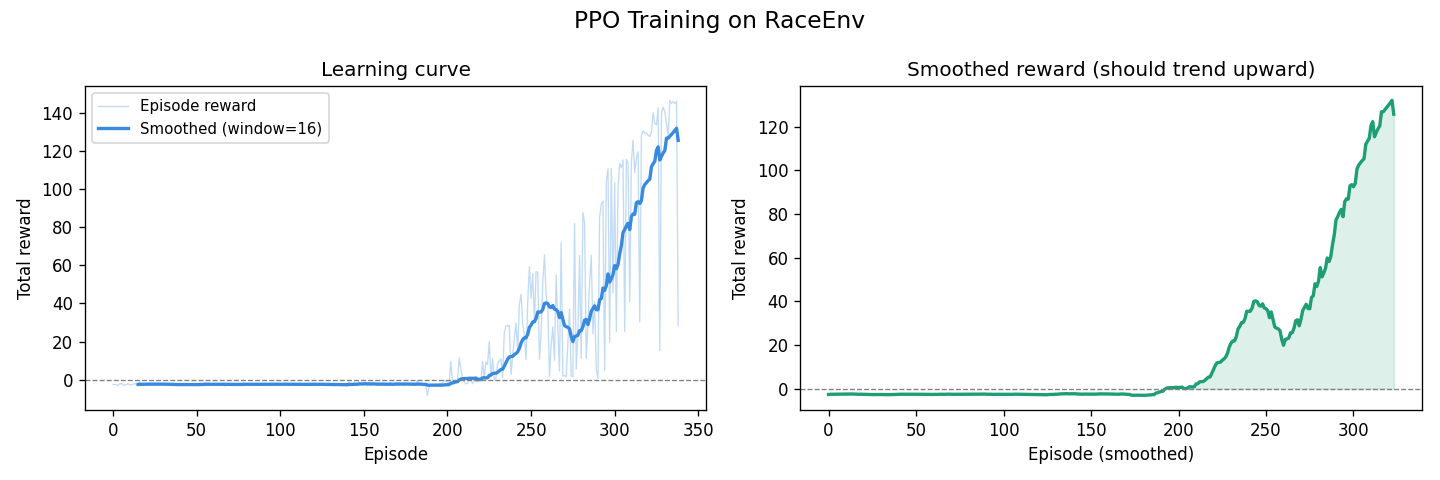

In [5]:
from IPython.display import Image
Image("results/training_curve.png")